In [16]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential, Model
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPool2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.datasets.fashion_mnist import load_data
from keras.utils import to_categorical
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'

```text
# Fashion MNIST 데이터세트
# Label     Category
# 0         티셔츠/상의
# 1         바지
# 2         스웨터
# 3         드레스
# 4         코트
# 5         샌들
# 6         셔츠
# 7         운동화
# 8         가방
# 9         부츠

In [17]:
(x_train, y_train),(x_test, y_test) = load_data()

In [18]:
x_train.shape

(60000, 28, 28)

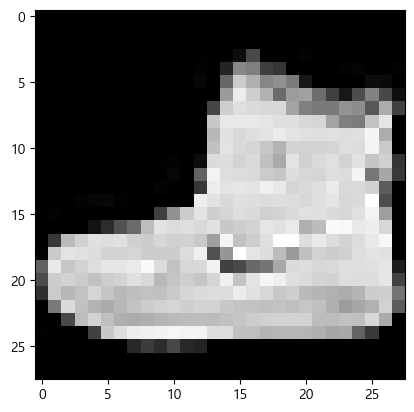

In [19]:
plt.imshow( x_train[0], cmap='gray')
plt.show()

In [20]:
y_train[0]

np.uint8(9)

In [21]:
model = Sequential()
model.add( Flatten( input_shape=(28,28) ) ) # x = x.reshape(n,28*28)
model.add( Dense( units=64, activation='relu')) #w:784x64  z = matmul(x,w)+b hx=relu(z)
model.add( Dense( units=32, activation='relu')) #w: 64x32   z = matmul(hx, w) +b hx=relu(z)
model.add( Dense( units=10, activation='softmax')) #w: 32x10  z= matmul(hx,w)+b hx=softmax(z)
model.compile( loss='sparse_categorical_crossentropy', optimizer='adam',metrics=['acc'])
model.fit(x_train/255, y_train, epochs=10)

Epoch 1/10


c:\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 976us/step - acc: 0.8182 - loss: 0.5198
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8608 - loss: 0.3887
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8720 - loss: 0.3534
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8803 - loss: 0.3270
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 997us/step - acc: 0.8856 - loss: 0.3115
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8906 - loss: 0.2942
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8953 - loss: 0.2852
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.8981 - loss: 0.2750
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.9002 - loss: 0.2681
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - acc: 0.9028 - loss: 0.2582


In [22]:
from sklearn.metrics import confusion_matrix

In [23]:
pred = model.predict( x_train/255 ).argmax(axis=1)
confusion_matrix( y_train, pred)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 631us/step


array([[5333,    7,   77,   86,   20,    0,  472,    0,    5,    0],
       [   6, 5942,    1,   41,    6,    0,    4,    0,    0,    0],
       [  57,    6, 4743,   93,  737,    0,  362,    0,    2,    0],
       [ 197,   56,   11, 5485,  163,    0,   84,    0,    4,    0],
       [   8,    7,  261,  164, 5235,    0,  324,    0,    1,    0],
       [   0,    1,    0,    0,    0, 5954,    2,   35,    1,    7],
       [ 778,    7,  344,  110,  353,    0, 4398,    0,   10,    0],
       [   0,    0,    0,    0,    0,   68,    0, 5755,    2,  175],
       [   2,    4,   14,   22,   28,    1,   35,    1, 5893,    0],
       [   1,    0,    0,    0,    0,   23,    0,  124,   10, 5842]])

## cnn

In [24]:
conv = Conv2D( 32, kernel_size=(3,3), strides=1, input_shape=(28,28,1) )
conv(  x_train[0].reshape( 1,28,28,1)/255  )

c:\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<tf.Tensor: shape=(1, 26, 26, 32), dtype=float32, numpy=
array([[[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

        [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.0

In [25]:
conv = Conv2D( 32, kernel_size=(3,3), strides=1, input_shape=(28,28,1) )
c = conv(  x_train[0].reshape( 1,28,28,1)/255  )
# c =Conv2D(64, kernel_size=(3,3), activation='relu')(c)
conv = Conv2D(64, kernel_size=(3,3), activation='relu')
c = conv(c) #1, 24, 24, 64
mx = MaxPool2D( pool_size=(2,2))(c) 
mx #1,12,12,64

<tf.Tensor: shape=(1, 12, 12, 64), dtype=float32, numpy=
array([[[[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         ...,
         [3.4030661e-02, 2.7841505e-02, 3.0732660e-02, ...,
          3.1933850e-03, 8.5307896e-04, 2.7375909e-02],
         [3.8537430e-03, 3.0073801e-03, 2.4545707e-03, ...,
          8.2221581e-04, 9.6642994e-04, 2.1104137e-03],
         [8.4531272e-04, 1.2954449e-03, 1.4793429e-03, ...,
          1.8689132e-03, 2.3903653e-03, 8.6729327e-05]],

        [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],

In [ ]:
conv1 = Conv2D(32, kernel_size=(3,3), strides=1, input_shape=(28,28,1))
# filters(32) : 사용할 필터(커널) 개수 -> 출력 채널 수
# kernel_size : 필터의 공간 크기 (3x3)
# strides     : 필터가 입력 위를 이동하는 간격
# input_shape : (높이, 너비, 채널 수) -> 정해져 있음
conv2 = Conv2D(64, kernel_size=(3,3), activation='relu')

c = conv1(x_train[0].reshape(1, 28, 28, 1) / 255)    # forward 연산 -> (1, 26, 26, 32)
c = conv2(c) # -> (1, 24, 24, 64)
mx = MaxPool2D(pool_size=(2,2))(c)  # -> (1, 12, 12, 64)
mx

In [ ]:
# 학습대상 w 파라미터수
# 1. 3x3x32 특징추출기
# 2. 3x3x64
# 3. 9216x64 분류기
# 4. 464x10

model = Sequential()
# 특징추출기 
model.add(Conv2D(32, kernel_size=(3,3), strides=1,
                input_shape=(28,28,1),activation='relu', padding='same')) 
# 32, 3,3 정해진값X  // strides=1: 한칸씩 이동 / (28,28,1)은 고정
# shape =(60000, 26, 26, 32) -> # (26-3)/1 +1 = 23  
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2))) # 60000,12,12,64 # 지정한 커널에서 가장 큰 값 추출
##------------------특징추출기

# 분류기
model.add(Flatten())
model.add(Dense(units=64, activation='relu')) # 10816*64 
model.add(Dense(units=10, activation='softmax')) # 64*10
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])
# model.summary() 파라미터수 확인
model.fit(x_train.reshape(60000,28,28,1)/255, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - acc: 0.8692 - loss: 0.3640
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - acc: 0.9164 - loss: 0.2263
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - acc: 0.9344 - loss: 0.1766
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - acc: 0.9483 - loss: 0.1392
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - acc: 0.9598 - loss: 0.1077
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.9698 - loss: 0.0807
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - acc: 0.9762 - loss: 0.0633
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - acc: 0.9820 - loss: 0.0487
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - acc: 0.9854 - loss: 0.0387
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.9875 - loss: 0.0342


In [ ]:
x = model.layers[0](x_test[0].reshape(1,28,28,1)/255)
x = model.layers[1](x)
x = model.layers[2](x) #maxpool
x = model.layers[3](x) # (1, 13*13*64)
x = model.layers[4](x) # (1, 10816)  (10816X64)
x = model.layers[5](x)
x 

<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[7.3316901e-16, 1.1061066e-21, 2.1678710e-17, 2.0408387e-13,
        8.3013749e-22, 7.2911937e-12, 1.9781891e-16, 3.6642958e-10,
        2.5150536e-16, 1.0000000e+00]], dtype=float32)>

In [ ]:
model.layers

[<Conv2D name=conv2d_3, built=True>,
 <Conv2D name=conv2d_4, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten_1, built=True>,
 <Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>]

In [30]:
model.predict(x_test[0].reshape(1,28,28,1)/255).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


array([9])

In [ ]:
x_test[0].shape

(28, 28)

In [31]:
model.save('fashion.keras')